# 02 — Simulated Annealing

**Curso:** Inteligencia Artificial — Optimización

Este notebook contiene ejemplos guiados y actividades para desarrollar en clase.

## Objetivos

- comprender por qué aceptar temporalmente soluciones peores puede ser útil;
- implementar Simulated Annealing desde cero;
- interpretar el efecto de la temperatura y el calendario de enfriamiento;
- comparar Simulated Annealing con Hill Climbing.

![HillClimbing](https://drive.google.com/uc?export=view&id=13a1dTy2bf9BsgeSZH-cXqJndS1ZKU4DP)



## 1. Un paisaje con varios óptimos

Maximizaremos una función unidimensional multimodal:

$$
f(x)=\sin(3x)+0.35\sin(9x)-0.03(x-2)^2
$$

El algoritmo solo observará valores cercanos al estado actual.

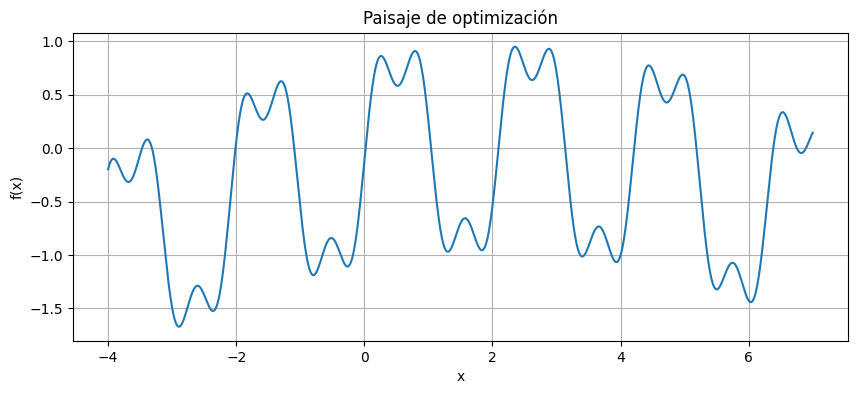

Mejor punto aproximado en la malla: x=2.355, f(x)=0.951


In [ ]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

SEED = 21
random.seed(SEED)
np.random.seed(SEED)


def objective(x):
    return np.sin(3 * x) + 0.35 * np.sin(9 * x) - 0.03 * (x - 2) ** 2

LOWER, UPPER = -4.0, 7.0
xs = np.linspace(LOWER, UPPER, 1500)
ys = objective(xs)

plt.figure(figsize=(10, 4))
plt.plot(xs, ys)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Paisaje de optimización')
plt.grid(True)
plt.show()

best_grid_x = xs[np.argmax(ys)]
print(f'Mejor punto aproximado en la malla: x={best_grid_x:.3f}, f(x)={objective(best_grid_x):.3f}')

## 2. Hill Climbing estocástico como línea base

Propondremos un vecino mediante una perturbación aleatoria pequeña. Hill Climbing acepta el candidato únicamente cuando mejora la función objetivo.

In [ ]:
def random_neighbor(x, step_size, rng, lower=LOWER, upper=UPPER):
    candidate = x + rng.uniform(-step_size, step_size)
    return min(upper, max(lower, candidate))


def stochastic_hill_climbing(x0, iterations=300, step_size=0.35, seed=0):
    rng = random.Random(seed)
    x = x0
    trajectory = [(x, float(objective(x)))]

    for _ in range(iterations):
        candidate = random_neighbor(x, step_size, rng)
        if objective(candidate) > objective(x):
            x = candidate
        trajectory.append((x, float(objective(x))))

    return x, trajectory

x0 = -2.5
hill_x, hill_trajectory = stochastic_hill_climbing(x0, seed=SEED)
print(f'Hill Climbing: x={hill_x:.3f}, f(x)={objective(hill_x):.3f}')

Hill Climbing: x=-2.603, f(x)=-1.288


## 3. Regla de aceptación

Sea

$$
\Delta = f(x')-f(x)
$$

Para maximización:

- si $\Delta>0$, aceptamos el candidato;
- si $\Delta\leq 0$, lo aceptamos con probabilidad

$$
P(\text{aceptar})=\exp\left(\frac{\Delta}{T}\right)
$$

Cuando $T$ es alta, el algoritmo explora. Cuando $T$ disminuye, se vuelve más selectivo.

In [ ]:
def simulated_annealing(
    x0,
    iterations=800,
    initial_temperature=1.5,
    cooling_rate=0.992,
    step_size=0.45,
    seed=0
):
    rng = random.Random(seed)
    x = x0
    current_value = float(objective(x))
    best_x, best_value = x, current_value
    temperature = initial_temperature
    records = []

    for iteration in range(iterations):
        candidate = random_neighbor(x, step_size, rng)
        candidate_value = float(objective(candidate))
        delta = candidate_value - current_value

        probability = 1.0 if delta > 0 else math.exp(delta / max(temperature, 1e-12))
        accepted = rng.random() < probability

        if accepted:
            x, current_value = candidate, candidate_value

        if current_value > best_value:
            best_x, best_value = x, current_value

        records.append({
            'iteration': iteration,
            'x': x,
            'value': current_value,
            'best_value': best_value,
            'temperature': temperature,
            'delta': delta,
            'probability': probability,
            'accepted': accepted
        })
        temperature *= cooling_rate

    return best_x, best_value, records

sa_x, sa_value, records = simulated_annealing(x0, seed=SEED)
print(f'Simulated Annealing: x={sa_x:.3f}, f(x)={sa_value:.3f}')

Simulated Annealing: x=0.791, f(x)=0.911


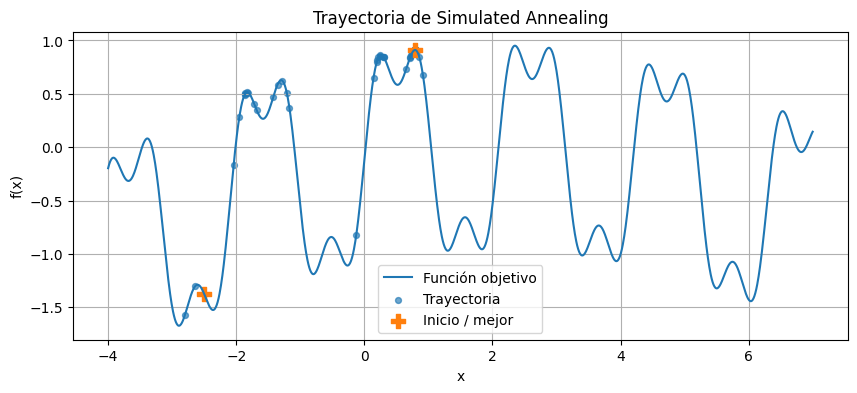

In [ ]:
trajectory_x = [r['x'] for r in records]
trajectory_y = [r['value'] for r in records]

plt.figure(figsize=(10, 4))
plt.plot(xs, ys, label='Función objetivo')
plt.scatter(trajectory_x[::12], trajectory_y[::12], s=18, alpha=0.65, label='Trayectoria')
plt.scatter([x0, sa_x], [objective(x0), sa_value], s=100, marker='P', label='Inicio / mejor')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Trayectoria de Simulated Annealing')
plt.legend()
plt.grid(True)
plt.show()

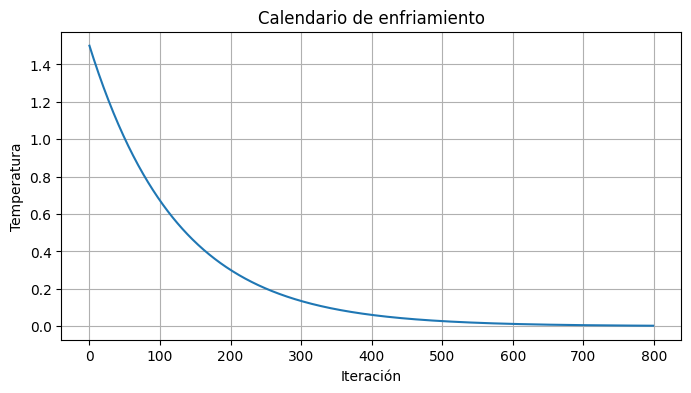

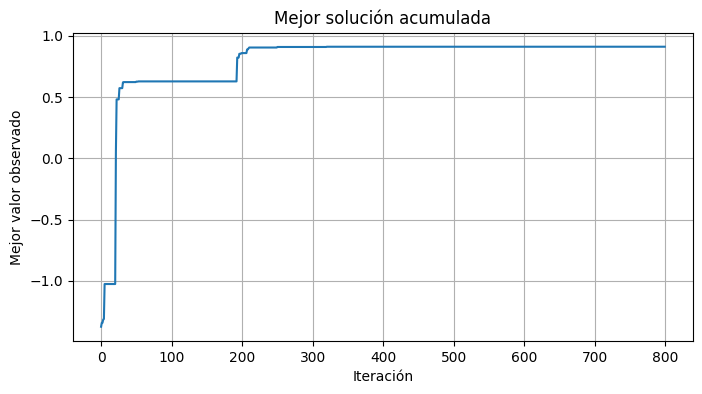

In [ ]:
iterations = [r['iteration'] for r in records]
temperatures = [r['temperature'] for r in records]
best_values = [r['best_value'] for r in records]

plt.figure(figsize=(8, 4))
plt.plot(iterations, temperatures)
plt.xlabel('Iteración')
plt.ylabel('Temperatura')
plt.title('Calendario de enfriamiento')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(iterations, best_values)
plt.xlabel('Iteración')
plt.ylabel('Mejor valor observado')
plt.title('Mejor solución acumulada')
plt.grid(True)
plt.show()

## 4. Comparación estadística

Una sola corrida puede ser engañosa. Compararemos ambos algoritmos usando múltiples semillas y el mismo punto inicial.

Hill Climbing — media: -0.380, mejor: 0.628
Simulated Annealing — media: 0.527, mejor: 0.951


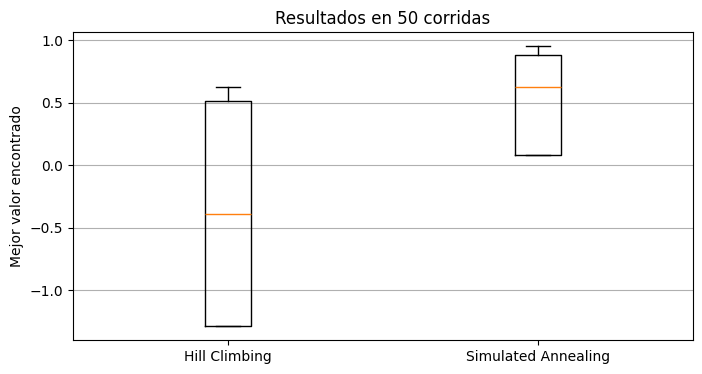

In [ ]:
hill_results = []
sa_results = []

for seed in range(50):
    hx, _ = stochastic_hill_climbing(x0, seed=seed)
    sx, sv, _ = simulated_annealing(x0, seed=seed)
    hill_results.append(float(objective(hx)))
    sa_results.append(sv)

print(f'Hill Climbing — media: {np.mean(hill_results):.3f}, mejor: {np.max(hill_results):.3f}')
print(f'Simulated Annealing — media: {np.mean(sa_results):.3f}, mejor: {np.max(sa_results):.3f}')

plt.figure(figsize=(8, 4))
plt.boxplot([hill_results, sa_results], tick_labels=['Hill Climbing', 'Simulated Annealing'])
plt.ylabel('Mejor valor encontrado')
plt.title('Resultados en 50 corridas')
plt.grid(True, axis='y')
plt.show()

## Actividades

### Actividad 1 — Temperatura inicial

Evalúa $T_0\in\{0.01,0.1,0.5,1,3,10\}$. Para cada valor realiza 30 corridas y registra:

- valor medio de la mejor solución;
- desviación estándar;
- porcentaje de corridas que alcanzan un valor cercano al mejor global aproximado.

Mejor global aproximado:
x = 2.355
f(x) = 0.951

Resultados de la actividad 1
----------------------------------------------------------------
T0       Media       Desviación       Cerca del global
0.01    0.537       0.203            0.0%
0.1     0.519       0.218            0.0%
0.5     0.419       0.280            0.0%
1       0.483       0.298            3.3%
3       0.639       0.336            13.3%
10      0.750       0.233            26.7%


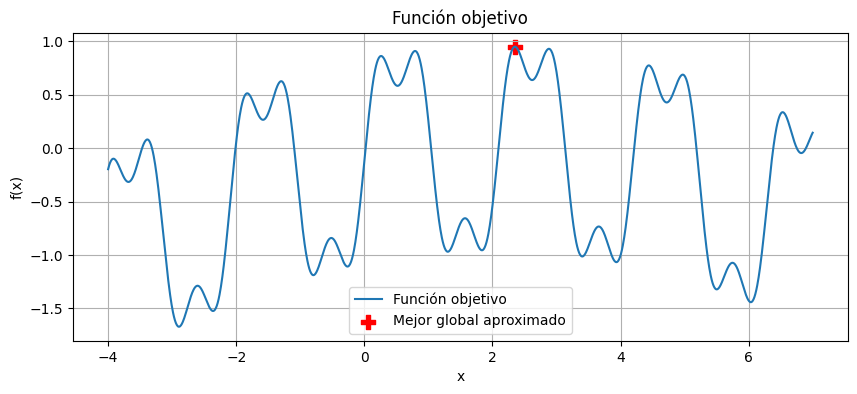

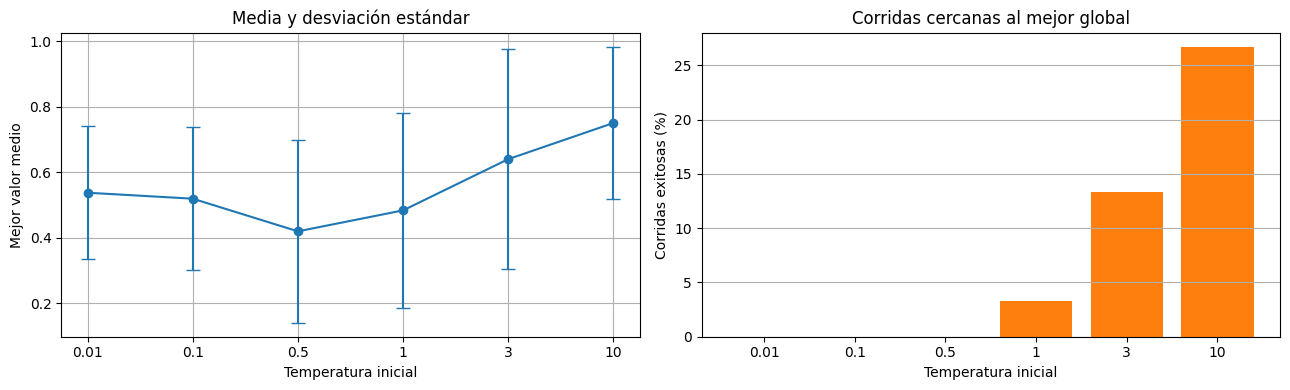


Conclusión:
La temperatura inicial T0 = 10 obtuvo el mayor valor medio, con un resultado de 0.750.
Una temperatura inicial muy baja reduce la exploración, porque el algoritmo casi no acepta soluciones peores.
Una temperatura más alta permite explorar diferentes regiones y escapar de óptimos locales, aunque también puede aceptar más movimientos desfavorables.


In [ ]:
# ACTIVIDAD 1 — TEMPERATURA INICIAL

import math
import random
import numpy as np
import matplotlib.pyplot as plt


# 1. Configuración general

SEED = 21
random.seed(SEED)
np.random.seed(SEED)

LOWER = -4.0
UPPER = 7.0
x0 = -2.5


# 2. Función objetivo

def objective(x):
    return (
        np.sin(3 * x)
        + 0.35 * np.sin(9 * x)
        - 0.03 * (x - 2) ** 2
    )


# 3. Generación de un vecino aleatorio

def random_neighbor(
    x,
    step_size,
    rng,
    lower=LOWER,
    upper=UPPER
):
    candidate = x + rng.uniform(-step_size, step_size)

    # Evita que el candidato se salga del intervalo permitido
    return min(upper, max(lower, candidate))


# 4. Algoritmo Simulated Annealing

def simulated_annealing(
    x0,
    iterations=800,
    initial_temperature=1.5,
    cooling_rate=0.992,
    step_size=0.45,
    seed=0
):
    rng = random.Random(seed)

    x = x0
    current_value = float(objective(x))

    best_x = x
    best_value = current_value

    temperature = initial_temperature
    records = []

    for iteration in range(iterations):

        # Generar una solución vecina
        candidate = random_neighbor(
            x,
            step_size,
            rng
        )

        candidate_value = float(objective(candidate))

        # Como estamos maximizando:
        # delta positivo significa que el candidato es mejor
        delta = candidate_value - current_value

        if delta > 0:
            probability = 1.0
        else:
            probability = math.exp(
                delta / max(temperature, 1e-12)
            )

        accepted = rng.random() < probability

        # Actualizar la solución actual si se acepta
        if accepted:
            x = candidate
            current_value = candidate_value

        # Guardar la mejor solución encontrada
        if current_value > best_value:
            best_x = x
            best_value = current_value

        records.append({
            "iteration": iteration,
            "x": x,
            "value": current_value,
            "best_value": best_value,
            "temperature": temperature,
            "delta": delta,
            "probability": probability,
            "accepted": accepted
        })

        # Disminuir la temperatura
        temperature *= cooling_rate

    return best_x, best_value, records


# 5. Aproximación del mejor valor global

xs = np.linspace(
    LOWER,
    UPPER,
    1500
)

ys = objective(xs)

best_grid_position = np.argmax(ys)
global_approx_x = float(xs[best_grid_position])
global_approx = float(ys[best_grid_position])

print("Mejor global aproximado:")
print(f"x = {global_approx_x:.3f}")
print(f"f(x) = {global_approx:.3f}")


# 6. Experimento con diferentes temperaturas

temperatures_to_test = [
    0.01,
    0.1,
    0.5,
    1,
    3,
    10
]

experiment = []

# Una corrida se considera exitosa si queda a una distancia
# máxima de 0.02 del mejor valor global aproximado
tolerance = 0.02

for temperature in temperatures_to_test:

    values = []

    for seed in range(30):

        best_x, best_value, records = simulated_annealing(
            x0=x0,
            iterations=800,
            initial_temperature=temperature,
            cooling_rate=0.992,
            step_size=0.45,
            seed=seed
        )

        values.append(best_value)

    values = np.array(values)

    mean_value = float(np.mean(values))
    standard_deviation = float(np.std(values))

    successful_runs = values >= (
        global_approx - tolerance
    )

    success_percentage = float(
        100 * np.mean(successful_runs)
    )

    experiment.append({
        "temperature": temperature,
        "mean": mean_value,
        "std": standard_deviation,
        "success_percentage": success_percentage
    })


# 7. Mostrar resultados

print("\nResultados de la actividad 1")
print("-" * 64)

print(
    "T0       Media       Desviación       Cerca del global"
)

for result in experiment:

    print(
        f"{result['temperature']:<8}"
        f"{result['mean']:<12.3f}"
        f"{result['std']:<17.3f}"
        f"{result['success_percentage']:.1f}%"
    )


# 8. Gráfica de la función objetivo

plt.figure(figsize=(10, 4))

plt.plot(
    xs,
    ys,
    label="Función objetivo"
)

plt.scatter(
    [global_approx_x],
    [global_approx],
    color="red",
    s=100,
    marker="P",
    label="Mejor global aproximado"
)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Función objetivo")
plt.legend()
plt.grid(True)
plt.show()


# 9. Gráficas de los resultados

temperatures = [
    result["temperature"]
    for result in experiment
]

means = [
    result["mean"]
    for result in experiment
]

standard_deviations = [
    result["std"]
    for result in experiment
]

success_percentages = [
    result["success_percentage"]
    for result in experiment
]

positions = range(len(temperatures))

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4)
)


# Gráfica de media y desviación estándar

axes[0].errorbar(
    positions,
    means,
    yerr=standard_deviations,
    marker="o",
    capsize=5
)

axes[0].set_xticks(
    positions,
    temperatures
)

axes[0].set_xlabel(
    "Temperatura inicial"
)

axes[0].set_ylabel(
    "Mejor valor medio"
)

axes[0].set_title(
    "Media y desviación estándar"
)

axes[0].grid(True)


# Gráfica del porcentaje de éxito

axes[1].bar(
    positions,
    success_percentages,
    color="tab:orange"
)

axes[1].set_xticks(
    positions,
    temperatures
)

axes[1].set_xlabel(
    "Temperatura inicial"
)

axes[1].set_ylabel(
    "Corridas exitosas (%)"
)

axes[1].set_title(
    "Corridas cercanas al mejor global"
)

axes[1].grid(
    True,
    axis="y"
)

plt.tight_layout()
plt.show()


# 10. Conclusión automática

best_temperature = max(
    experiment,
    key=lambda result: (
        result["mean"],
        -result["std"]
    )
)

print("\nConclusión:")

print(
    f"La temperatura inicial T0 = "
    f"{best_temperature['temperature']} obtuvo el mayor "
    f"valor medio, con un resultado de "
    f"{best_temperature['mean']:.3f}."
)

print(
    "Una temperatura inicial muy baja reduce la exploración, "
    "porque el algoritmo casi no acepta soluciones peores."
)

print(
    "Una temperatura más alta permite explorar diferentes "
    "regiones y escapar de óptimos locales, aunque también "
    "puede aceptar más movimientos desfavorables."
)

### Actividad 2 — Enfriamiento

Compara diferentes valores de $\alpha$ en

$$
T_{t+1}=\alpha T_t
$$

Explica por qué un enfriamiento demasiado rápido puede convertir el algoritmo en Hill Climbing.

alpha | media  | desviación | peores aceptadas | temperatura final
0.900 | 0.381 | 0.283      | 1.5%            | 0.000000
0.950 | 0.383 | 0.286      | 3.2%            | 0.000000
0.980 | 0.447 | 0.312      | 7.9%            | 0.000000
0.992 | 0.556 | 0.336      | 21.8%            | 0.002429
0.999 | 0.851 | 0.183      | 69.9%            | 0.673724


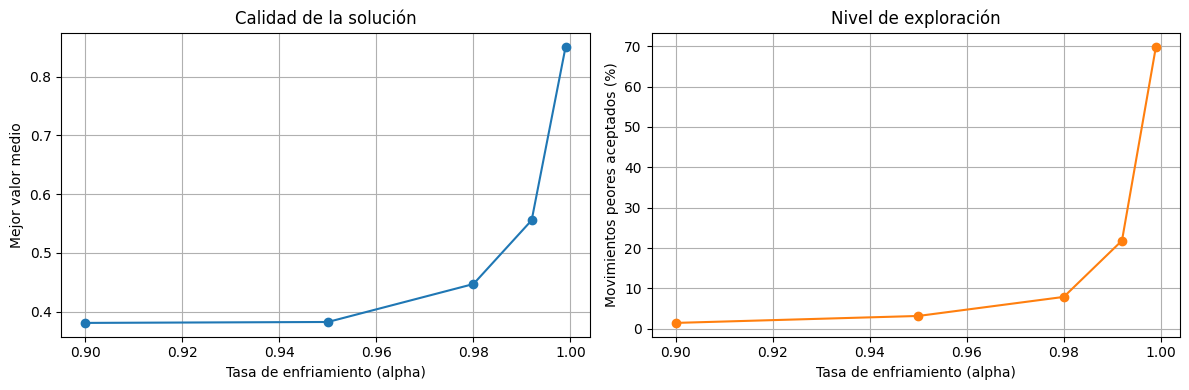

Conclusión: con un alpha pequeño la temperatura cae rápidamente y la
probabilidad de aceptar soluciones peores se aproxima pronto a cero.
En ese punto, el comportamiento se parece a Hill Climbing: casi solo acepta mejoras.


In [ ]:
# Actividad 2: comparación de calendarios de enfriamiento.
cooling_rates = [0.90, 0.95, 0.98, 0.992, 0.999]
cooling_experiment = []

for alpha in cooling_rates:
    values = []
    accepted_worse_rates = []
    for seed in range(30):
        _, value, run_records = simulated_annealing(
            x0, initial_temperature=1.5, cooling_rate=alpha, seed=seed
        )
        values.append(value)
        worse = [r for r in run_records if r['delta'] <= 0]
        accepted_worse = sum(r['accepted'] for r in worse)
        accepted_worse_rates.append(100 * accepted_worse / len(worse))

    cooling_experiment.append({
        'alpha': alpha,
        'mean': float(np.mean(values)),
        'std': float(np.std(values)),
        'accepted_worse': float(np.mean(accepted_worse_rates)),
        'final_temperature': 1.5 * alpha**800
    })

print('alpha | media  | desviación | peores aceptadas | temperatura final')
for result in cooling_experiment:
    print(f"{result['alpha']:.3f} | {result['mean']:.3f} | {result['std']:.3f}      | "
          f"{result['accepted_worse']:.1f}%            | {result['final_temperature']:.6f}")

alphas = [r['alpha'] for r in cooling_experiment]
means = [r['mean'] for r in cooling_experiment]
worse_rates = [r['accepted_worse'] for r in cooling_experiment]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(alphas, means, marker='o')
axes[0].set(xlabel='Tasa de enfriamiento (alpha)', ylabel='Mejor valor medio',
            title='Calidad de la solución')
axes[0].grid(True)
axes[1].plot(alphas, worse_rates, marker='o', color='tab:orange')
axes[1].set(xlabel='Tasa de enfriamiento (alpha)',
            ylabel='Movimientos peores aceptados (%)', title='Nivel de exploración')
axes[1].grid(True)
plt.tight_layout(); plt.show()

print('Conclusión: con un alpha pequeño la temperatura cae rápidamente y la')
print('probabilidad de aceptar soluciones peores se aproxima pronto a cero.')
print('En ese punto, el comportamiento se parece a Hill Climbing: casi solo acepta mejoras.')


### Actividad 3 — Problema discreto

Adapta Simulated Annealing al problema de hospitales del notebook anterior. Recuerda que, al minimizar, puedes definir

$$
\Delta = C(	actual)-C(candidato)
$$

para conservar la misma lógica de aceptación usada en este notebook.

Mejor costo encontrado: 56
Ubicación de hospitales: [(2, 5), (3, 12), (7, 3)]
Costo medio de 30 corridas: 56.1


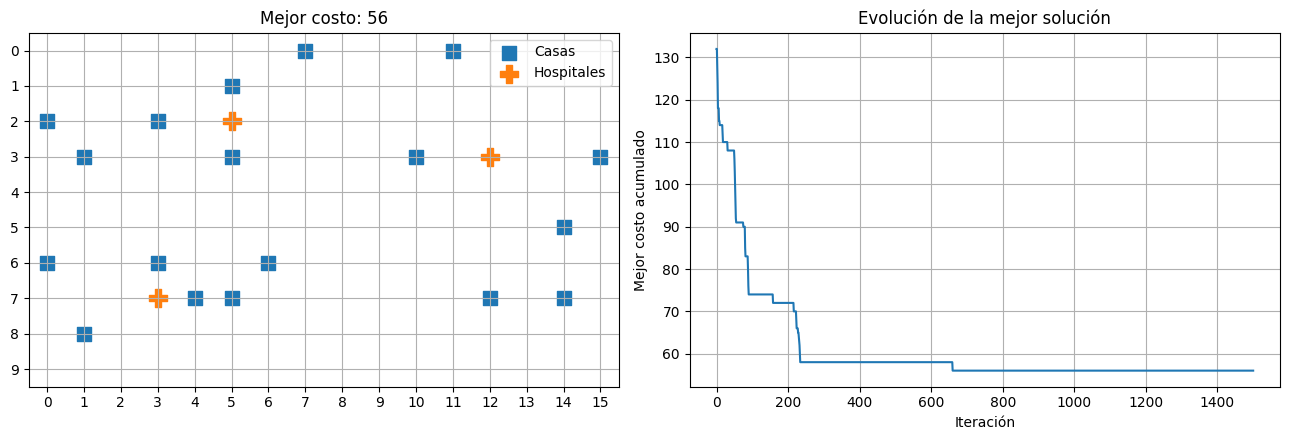

Conclusión: Simulated Annealing puede aceptar temporalmente ubicaciones
más costosas, lo que le permite escapar de óptimos locales. La mejor
configuración observada se guarda aunque el estado actual empeore después.


In [ ]:
# Actividad 3: Simulated Annealing para ubicar hospitales.
GRID_HEIGHT, GRID_WIDTH = 10, 16
NUM_HOUSES, NUM_HOSPITALS = 18, 3
hospital_rng = random.Random(8)
all_cells = [(r, c) for r in range(GRID_HEIGHT) for c in range(GRID_WIDTH)]
houses = set(hospital_rng.sample(all_cells, NUM_HOUSES))
available_cells = list(set(all_cells) - houses)

def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def hospital_cost(houses, hospitals):
    return sum(min(manhattan(house, hospital) for hospital in hospitals)
               for house in houses)

def hospital_neighbors(height, width, houses, hospitals):
    neighbors = []
    for hospital in hospitals:
        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            candidate = (hospital[0] + dr, hospital[1] + dc)
            if not (0 <= candidate[0] < height and 0 <= candidate[1] < width):
                continue
            if candidate in houses or candidate in hospitals:
                continue
            new_state = set(hospitals)
            new_state.remove(hospital)
            new_state.add(candidate)
            neighbors.append(new_state)
    return neighbors

def hospital_simulated_annealing(initial_state, iterations=1500,
                                 initial_temperature=8.0,
                                 cooling_rate=0.996, seed=0):
    rng = random.Random(seed)
    current = set(initial_state)
    current_cost = hospital_cost(houses, current)
    best, best_cost = set(current), current_cost
    temperature = initial_temperature
    history = [best_cost]

    for _ in range(iterations):
        neighbors = hospital_neighbors(
            GRID_HEIGHT, GRID_WIDTH, houses, current
        )
        if not neighbors:
            break
        candidate = set(rng.choice(neighbors))
        candidate_cost = hospital_cost(houses, candidate)
        # Al minimizar, delta positivo significa que el candidato es mejor.
        delta = current_cost - candidate_cost
        probability = 1.0 if delta > 0 else math.exp(
            delta / max(temperature, 1e-12)
        )
        if rng.random() < probability:
            current, current_cost = candidate, candidate_cost
        if current_cost < best_cost:
            best, best_cost = set(current), current_cost
        history.append(best_cost)
        temperature *= cooling_rate

    return best, best_cost, history

hospital_runs = []
for seed in range(30):
    start_rng = random.Random(seed)
    initial = set(start_rng.sample(available_cells, NUM_HOSPITALS))
    solution, cost, history = hospital_simulated_annealing(initial, seed=seed)
    hospital_runs.append((cost, solution, history))

best_hospital_cost, best_hospitals, best_history = min(
    hospital_runs, key=lambda run: run[0]
)
print('Mejor costo encontrado:', best_hospital_cost)
print('Ubicación de hospitales:', sorted(best_hospitals))
print('Costo medio de 30 corridas:', round(np.mean([r[0] for r in hospital_runs]), 2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
hr, hc = zip(*houses)
rr, cc = zip(*best_hospitals)
axes[0].scatter(hc, hr, marker='s', s=100, label='Casas')
axes[0].scatter(cc, rr, marker='P', s=180, label='Hospitales')
axes[0].set(xlim=(-0.5, GRID_WIDTH - 0.5),
            ylim=(GRID_HEIGHT - 0.5, -0.5), title=f'Mejor costo: {best_hospital_cost}')
axes[0].set_xticks(range(GRID_WIDTH)); axes[0].set_yticks(range(GRID_HEIGHT))
axes[0].grid(True); axes[0].legend()
axes[1].plot(best_history)
axes[1].set(xlabel='Iteración', ylabel='Mejor costo acumulado',
            title='Evolución de la mejor solución')
axes[1].grid(True)
plt.tight_layout(); plt.show()

print('Conclusión: Simulated Annealing puede aceptar temporalmente ubicaciones')
print('más costosas, lo que le permite escapar de óptimos locales. La mejor')
print('configuración observada se guarda aunque el estado actual empeore después.')


## Preguntas de cierre

1. ¿Por qué Simulated Annealing conserva la mejor solución observada, además de la solución actual?

Porque el algoritmo puede aceptar temporalmente una solución peor para explorar. Si solo devolviera el estado final, podría perder una solución de mayor calidad encontrada anteriormente. Guardar la mejor garantiza que el resultado no sea peor que el mejor punto visitado.


2. ¿Qué ocurre si la temperatura nunca disminuye?

El algoritmo continúa aceptando soluciones peores con una probabilidad importante y no se concentra completamente en una región prometedora. Mantiene mucha exploración, pero puede oscilar y terminar lejos de la mejor solución.

3. ¿Qué ocurre si la temperatura inicial es prácticamente cero?

La probabilidad de aceptar una solución peor es casi cero desde el comienzo. Por eso, Simulated Annealing se comporta de manera muy parecida a Hill Climbing y puede quedar atrapado en un óptimo local.

4. ¿Simulated Annealing garantiza el óptimo global con un número finito de iteraciones?

No. Puede aumentar la probabilidad de encontrarlo mediante una temperatura y un enfriamiento adecuados, pero con una cantidad finita de iteraciones no existe garantía de visitar el óptimo global.